In [1]:
#RICE LEAF DISEASE DETECTION PROJECT
#DATA ANALYSIS


In [6]:
                       #DATA ANALYSIS

#IMPORTING LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
pip install opencv-python


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 3.0 MB/s eta 0:00:14
   - -------------------------------------- 1.6/40.2 MB 3.7 MB/s eta 0:00:11
   -- ------------------------------------- 2.4/40.2 MB 3.7 MB/s eta 0:00:11
   --- ------------------------------------ 3.4/40.2 MB 3.9 MB/s eta 0:00:10
   ---- ----------------------------------- 4.2/40.2 MB 3.9 MB/s eta 0:00:10
   ---- ----------------------------------- 5.0/40.2 MB 3.9 MB/s eta 0:00:09
   ----- ---------------------------------- 6.0/40.2 MB 4.0 MB/s eta 0:00:09
   ------- -------------------------------- 7.1/40.2 MB 4.1 MB/s eta 0:00:09
   ------- -------------------------------- 7.9/40.2 MB 4.1 MB/s eta 0:00:08
   -------- ------------------------------- 8.9/40.2 MB 4.1 MB/s eta 0:00:08
   --------- ------------------------------ 9.7/40.2 MB 4.1 MB/s eta 0:00:08
   ---------- ----------------------------- 10.7/40.2 MB 4.2 MB/s eta 0:00:08
   -

In [3]:
dataset_path = r"C:\Users\Induja\OneDrive\Desktop\Rice leaf"
classes = os.listdir(dataset_path)
print("Classes:", classes)

Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [5]:
pip install tensorflow


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.0 which is incompatible.



   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 3.5 MB/s eta 0:01:41
   ---------------------------------------- 1.3/351.2 MB 3.1 MB/s eta 0:01:54
   ---------------------------------------- 1.6/351.2 MB 2.8 MB/s eta 0:02:06
   ---------------------------------------- 2.6/351.2 MB 3.0 MB/s eta 0:01:57
   ---------------------------------------- 3.7/351.2 MB 3.4 MB/s eta 0:01:43
    --------------------------------------- 4.5/351.2 MB 3.5 MB/s eta 0:01:39
    --------------------------------------- 5.5/351.2 MB 3.7 MB/s eta 0:01:35
    --------------------------------------- 6.3/351.2 MB 3.7 MB/s eta 0:01:33
    --------------------------------------- 7.1/351.2 MB 3.8 MB/s eta 0:01:32
    --------------------------------------- 8.1/351.2 MB 3.8 MB/s eta 0:01:30
   - -------------------------------------- 9.2/351.2 MB 3.9 MB/s eta 0:01:28
   - -------------------------------------- 10.2/351.2 MB 4.0 MB/s eta

In [7]:
# COUNTING THE LENGTH OF THE DATA


for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(cls, len(os.listdir(path)))


Bacterial leaf blight 40
Brown spot 40
Leaf smut 39


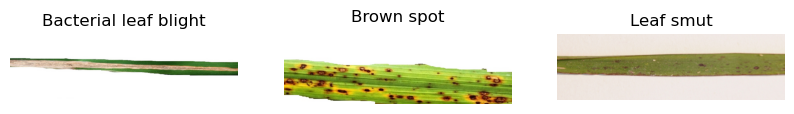

In [8]:
# DATA VISUALIZATION

import random

plt.figure(figsize=(10,6))

for i,cls in enumerate(classes):
    img_path = os.path.join(dataset_path, cls, random.choice(os.listdir(os.path.join(dataset_path,cls))))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [9]:
#REPORT FOR DATA VISUALIZATION

#Here we can see the different affected leaves which shows the stripes, spots and dark spots.
#As the image are in different size now the data should be resized for consistent shape as the CNN needs one consistent shape.



In [10]:
#RESIZING THE IMAGES

In [11]:
IMG_SIZE = 128

data = []
labels = []

for cls in classes:
    path = os.path.join(dataset_path, cls)
    
    for img in os.listdir(path):
        image = cv2.imread(os.path.join(path,img))
        image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))
        
        data.append(image)
        labels.append(cls)

data = np.array(data)/255.0
labels = np.array(labels)

In [12]:
#LABEL ENCODER

from sklearn.preprocessing import LabelEncoder
laben = LabelEncoder()

labels = laben.fit_transform(labels)

In [13]:
#TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [15]:
X_train.shape

(95, 128, 128, 3)

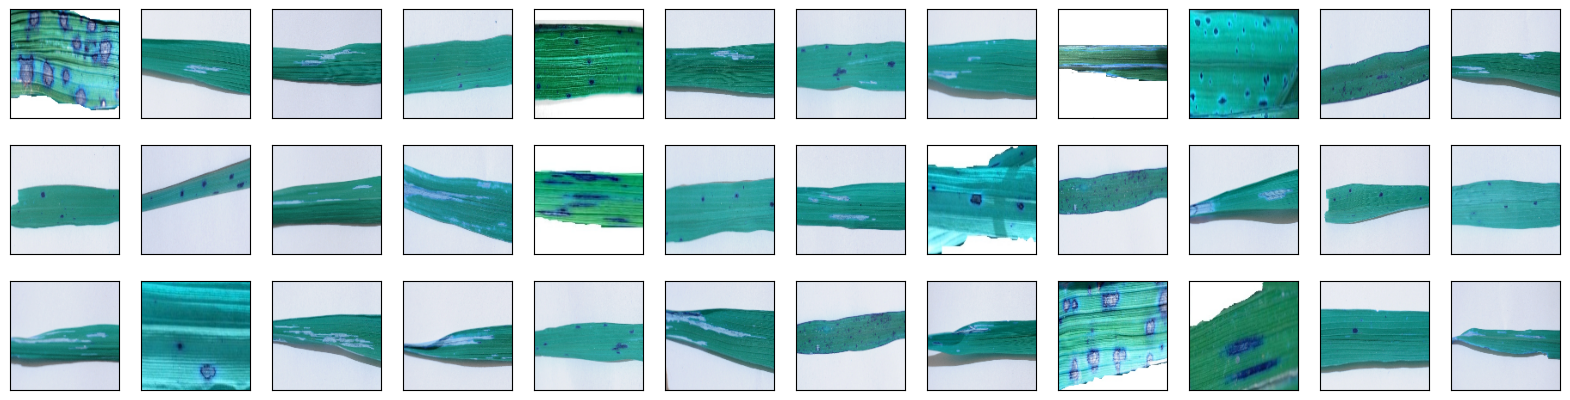

In [16]:
fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_train[i]))

In [17]:
X_train

array([[[[0.16078431, 0.61176471, 0.76862745],
         [0.05882353, 0.45882353, 0.59215686],
         [0.02352941, 0.36862745, 0.43529412],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[0.02352941, 0.47843137, 0.58039216],
         [0.11764706, 0.45882353, 0.5254902 ],
         [0.19607843, 0.56470588, 0.56470588],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[0.19607843, 0.61568627, 0.63529412],
         [0.17254902, 0.56862745, 0.54509804],
         [0.14509804, 0.52941176, 0.47058824],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        ...,

        [[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]

In [18]:
Y_train


NameError: name 'Y_train' is not defined

In [19]:
y_train


array([1, 0, 0, 1, 2, 0, 1, 0, 0, 1, 2, 0, 1, 1, 0, 0, 2, 1, 0, 1, 2, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 2, 0, 1, 2, 1, 0, 0, 2, 2, 0, 0, 0, 2, 0,
       0, 0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1,
       0, 2, 1, 1, 2, 0, 0, 2, 0, 1, 0, 0, 0, 2, 2, 2, 2, 1, 2, 2, 2, 0,
       1, 1, 2, 0, 2, 1, 2])

In [20]:

#CNN MODEL IMPLEMENTATION


model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Induja\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test,y_test)
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3263 - loss: 1.2050 - val_accuracy: 0.3750 - val_loss: 1.0930
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 947ms/step - accuracy: 0.4105 - loss: 1.1093 - val_accuracy: 0.4583 - val_loss: 1.0729
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 742ms/step - accuracy: 0.4632 - loss: 1.0642 - val_accuracy: 0.4167 - val_loss: 1.0367
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 806ms/step - accuracy: 0.4842 - loss: 0.9931 - val_accuracy: 0.5417 - val_loss: 0.9414
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 864ms/step - accuracy: 0.4526 - loss: 0.9887 - val_accuracy: 0.5000 - val_loss: 0.9591
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 915ms/step - accuracy: 0.5368 - loss: 0.9492 - val_accuracy: 0.7083 - val_loss: 0.8861
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 939ms/step - accuracy: 0.6421 - loss: 0.8858 - val_accuracy: 0.5833 - val_loss: 0.8187
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6000 - loss: 0.8134 - val_accuracy: 0.7917 - val_loss: 0.70

In [22]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
Accuracy: 0.7916666666666666
              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.67      1.00      0.80         8
           2       1.00      0.56      0.71         9

    accuracy                           0.79        24
   macro avg       0.84      0.80      0.79        24
weighted avg       0.85      0.79      0.78        24



In [23]:
# DATA AUGMENTATION

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

In [24]:
datagen.fit(X_train)

history_aug = model.fit(
    datagen.flow(X_train,y_train,batch_size=16),
    epochs=20,
    validation_data=(X_test,y_test)
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 453ms/step - accuracy: 0.7368 - loss: 0.7962 - val_accuracy: 0.6250 - val_loss: 0.7829
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 447ms/step - accuracy: 0.7158 - loss: 0.6480 - val_accuracy: 0.6667 - val_loss: 0.6290
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 446ms/step - accuracy: 0.5895 - loss: 0.9528 - val_accuracy: 0.7083 - val_loss: 0.6348
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 428ms/step - accuracy: 0.6526 - loss: 0.8114 - val_accuracy: 0.8333 - val_loss: 0.5835
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 439ms/step - accuracy: 0.7263 - loss: 0.6613 - val_accuracy: 0.8333 - val_loss: 0.5151
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 426ms/step - accuracy: 0.7474 - loss: 0.5111 - val_accuracy: 0.8333 - val_loss: 0.5439
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - accuracy: 0.7158 - loss: 0.5716 - val_accuracy: 0.8333 - val_loss: 0.3258
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.8105 - loss: 0.5665 - val_accuracy: 0.7083 - val_loss:

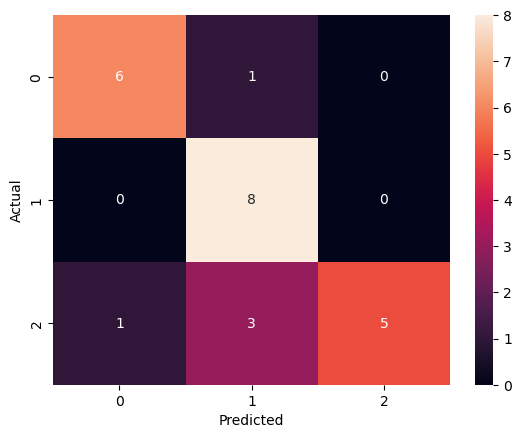

In [25]:
import seaborn as sns

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
#MODEL EVALUATION


score = model.evaluate(X_test, y_test, verbose=0)
accuracy = 100*score[1]

# print test accuracy
print('Test accuracy: %.4f%%' % accuracy)

Test accuracy: 79.1667%
